In [1]:
import pandas as pd

data = {
    "price":[3200, 4500, 5100, 3900, 6200, 5800, 4700, 5200],
    "area":[40, 55, 60, 45, 70, 65, 50, 62]
}

df = pd.DataFrame(data)
df.to_csv("real_estate.csv", index=False)
df

,price,area
0,3200,40
1,4500,55
2,5100,60
3,3900,45
4,6200,70
5,5800,65
6,4700,50
7,5200,62


In [2]:
df = pd.read_csv("real_estate.csv")
df


,price,area
0,3200,40
1,4500,55
2,5100,60
3,3900,45
4,6200,70
5,5800,65
6,4700,50
7,5200,62


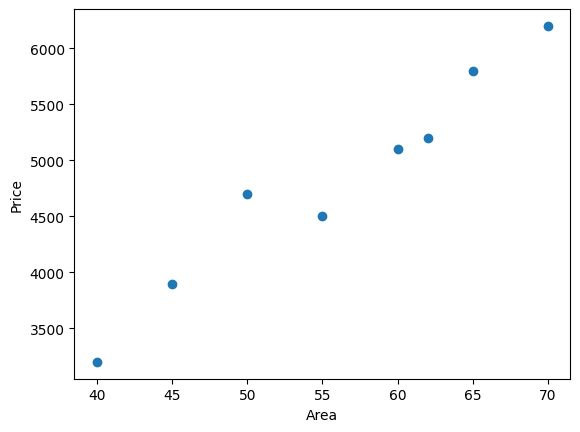

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# データ（もしdfが消えていたら再作成）
data = {
    "price":[3200, 4500, 5100, 3900, 6200, 5800, 4700, 5200],
    "area":[40, 55, 60, 45, 70, 65, 50, 62]
}
df = pd.DataFrame(data)

X = df[["area"]]   # ←二重カッコが重要（2次元）
y = df["price"]

model = LinearRegression().fit(X, y)
pred = model.predict([[55]])[0]
pred

C:\Users\ninav\miniconda3\envs\ai\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(4744.16961130742)

In [2]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(df[["area"]])
print("R2 =", r2_score(df["price"], y_pred))
print("MAE =", mean_absolute_error(df["price"], y_pred))

R2 = 0.9497246311872906
MAE = 174.8864209994951


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 学習用 / テスト用に分割
X = df[["area"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# 学習
model = LinearRegression()
model.fit(X_train, y_train)

# 予測（未知データ）
y_pred = model.predict(X_test)

print("R2 =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))

R2 = -2.141147588691592
MAE = 283.47406513872147


In [4]:
import pandas as pd
import numpy as np

# データを増やす（50件）
np.random.seed(0)

area = np.random.randint(30, 80, 50)
price = area * 80 + np.random.normal(0, 200, 50)

df = pd.DataFrame({"area": area, "price": price})
df.head()

,area,price
0,74,6038.248561
1,77,6003.444899
2,30,2311.153435
3,33,2570.962768
4,33,2463.639890


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 入力と出力
X = df[["area"]]
y = df["price"]

# 学習用 / テスト用に分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# モデル学習
model = LinearRegression()
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 精度評価
print("R2 =", r2_score(y_test, y_pred))
print("MAE =", mean_absolute_error(y_test, y_pred))

R2 = 0.9714936088135883
MAE = 154.0334512402515
